In [1]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
import itertools
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'parent_gesture'

WINDOW_SIZE_SAMPLES = 60
WINDOW_STRIDE_SAMPLES = 20
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians
WINDOW_GESTURE_MAJORITY_THRESHOLD = 0.4  # 40%

In [3]:
import pickle
from tensorflow.keras.models import load_model
# Load LSTM model from file
LSTM_MODEL_FILE = "best_class_gesture_lstm_padded_recognition_model.h5"
lstm_model = load_model(LSTM_MODEL_FILE)

LSTM_LABEL_ENCODER_FILE = "class_gesture_lstm_label_encoder.pkl"
with open(LSTM_LABEL_ENCODER_FILE, 'rb') as f:
    lstm_label_encoder = pickle.load(f)

In [4]:
import pickle
from tensorflow.keras.models import load_model
# Load LSTM model from file
TAP_LSTM_MODEL_FILE = "best_class_gesture_lstm_swipe_padded_recognition_model.h5"
tap_lstm_model = load_model(TAP_LSTM_MODEL_FILE)

TAP_LSTM_LABEL_ENCODER_FILE = "class_gesture_lstm_swipe_label_encoder.pkl"
with open(TAP_LSTM_LABEL_ENCODER_FILE, 'rb') as f:
    tap_lstm_label_encoder = pickle.load(f)

In [5]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    'Szenarien' AS gesture,
    'Szenarien' AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 0 ELSE 1 END AS is_gesture,
    -- Get marker type without the 'marker:' prefix and ':start' suffix
    SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) AS marker_label,
    (smt.group_id || '-' || mi.marker_type || '-' || mi.start_index) AS group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
WHERE rtParent.title = 'Szenarien'
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(DB_PATH) as conn:
    szenarien_df_raw = pd.read_sql_query(szenarien_query, conn)
szenarien_df_raw.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,1668ffd2-1939-41a9-97dc-906cc8041084,002f4422-1f7b-4859-8f03-467e1f752000,325,2025-10-07 14:11:50,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
1,7cc63c58-ff05-4c43-ace6-ce2038a4da66,002f4422-1f7b-4859-8f03-467e1f752000,326,2025-10-07 14:11:50,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
2,4e727221-45fa-432a-b972-5ee640c533a7,002f4422-1f7b-4859-8f03-467e1f752000,327,2025-10-07 14:11:50,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
3,cd025956-225d-45c0-9380-76c934284585,002f4422-1f7b-4859-8f03-467e1f752000,328,2025-10-07 14:11:50,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
4,2337a772-c876-4cd2-a5e7-ac42f6dad3ab,002f4422-1f7b-4859-8f03-467e1f752000,329,2025-10-07 14:11:50,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None


In [6]:
# add timestamp columns for szenarien_df
szenarien_df_raw['timestamp'] = pd.to_datetime(szenarien_df_raw['timestamp'])
szenarien_df_raw['time_diff'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
szenarien_df_raw['recordings_per_second'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
szenarien_df_raw['estimated_timestamp'] = szenarien_df_raw['timestamp'] + pd.to_timedelta(szenarien_df_raw['time_diff'] / szenarien_df_raw['recordings_per_second'], unit='s')
szenarien_df_raw = szenarien_df_raw.drop(columns=['time_diff', 'recordings_per_second'])

szenarien_df_raw["timestamp_ms"] = (szenarien_df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [7]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

In [8]:
# Stabilize szenarien_df
stabilized_szenarien_data = process_and_stabilize_touches(szenarien_df_raw.copy())
non_touch_cols_szenarien = [c for c in szenarien_df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_szenarien_df = szenarien_df_raw[non_touch_cols_szenarien].copy()
szenarien_df = final_szenarien_df.join(stabilized_szenarien_data)
print("Szenarien Stabilization Complete.")

Szenarien Stabilization Complete.


In [9]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        szenarien_df[col] = szenarien_df[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        szenarien_df[col] = szenarien_df.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        szenarien_df[col] = szenarien_df.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
szenarien_df['motor_angle'] = szenarien_df.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [10]:
# Set 0 for null values in szenarien_df touch columns
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    szenarien_df[position_col] = szenarien_df[position_col].fillna(0)
    szenarien_df[pressure_col] = szenarien_df[pressure_col].fillna(0)
    szenarien_df[channel_col] = szenarien_df[channel_col].fillna(0)
szenarien_df.isna().sum()

id                            0
session_task_id               0
session_task_row_index        0
timestamp                     0
button_pressed                0
motor_angle                   0
gesture                       0
parent_gesture                0
participant_id                0
is_gesture                    0
marker_label              21846
group_id                  21846
estimated_timestamp           0
timestamp_ms                  0
touch_1_position              0
touch_1_pressure              0
touch_1_channel               0
touch_2_position              0
touch_2_pressure              0
touch_2_channel               0
touch_3_position              0
touch_3_pressure              0
touch_3_channel               0
touch_4_position              0
touch_4_pressure              0
touch_4_channel               0
touch_5_position              0
touch_5_pressure              0
touch_5_channel               0
active_ids                    0
dtype: int64

## LSTM

In [11]:
# Add new features to the dataframe, for improved modeling
def create_feature_df(df_clean, smoothing_window=3, long_smoothing_window=10, inactive_window=30):
    # Create empty feature dataframe
    feature_df = df_clean.copy()
    additional_features = []

    def add_feature(name, values):
        feature_df[name] = values
        additional_features.append(name)

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    pressure_col = f'touch_1_pressure'
    rising_edge = ((feature_df[pressure_col] > 0.0) & (feature_df[pressure_col].shift(1) <= 0.0)).astype(int)
    tap_count = rising_edge.rolling(window=long_smoothing_window, min_periods=1).sum()
    for touch_num in range(2, 6):
        position_col = f'touch_{touch_num}_pressure'
        rising_edge = ((feature_df[position_col] > 0.0) & (feature_df[position_col].shift(1) <= 0.0)).astype(int)
        tap_count += rising_edge.rolling(window=long_smoothing_window, min_periods=1).sum()
    add_feature('total_tap_count', tap_count)

    # Smoothed Features
    for touch_num in range(1, 6):
        position_col = f'touch_{touch_num}_position'
        pressure_col = f'touch_{touch_num}_pressure'
        channel_col = f'touch_{touch_num}_channel'

        is_touching = (feature_df[pressure_col] > 0.0).astype(int)
        is_touching_shifted = (feature_df[pressure_col].rolling(window=2, min_periods=1).min() > 0.0).astype(int)

        # A touch is inactive, if it was touching for the whole inactive_window and has not moved more than TOUCH_MOVE_THRESHOLD
        inactive_touch = (is_touching.rolling(window=inactive_window, min_periods=1).sum() >= inactive_window - 1)
        position_diff_during_touch = feature_df[position_col].diff().fillna(0) * is_touching_shifted
        has_moved = (position_diff_during_touch.abs().rolling(window=inactive_window, min_periods=1).max() > TOUCH_MOVE_THRESHOLD)
        is_inactive_touch = inactive_touch & (~has_moved)
        add_feature(f'touch_{touch_num}_is_inactive_touch', is_inactive_touch.astype(int))
        # add_feature(f'touch_{touch_num}_inactive', inactive_touch.astype(int))
        # add_feature(f'touch_{touch_num}_has_moved', has_moved.astype(int))

        # Get the min and max distance to all other fingers
        other_positions = [f'touch_{i}_position' for i in range(1, 6) if i != touch_num]
        if other_positions:
            for other_pos_col in other_positions:
                other_touching = (feature_df[other_pos_col.replace('position', 'pressure')] > 0.0).astype(int)
                both_touching = is_touching * other_touching

                dist_to_other = short_dist(feature_df[position_col], feature_df[other_pos_col]) * both_touching
                add_feature(f'touch_{touch_num}_dist_to_{other_pos_col}', dist_to_other.rolling(window=smoothing_window, min_periods=1).mean())
                add_feature(f'touch_{touch_num}_dist_to_{other_pos_col}_diff', dist_to_other.diff().fillna(0))
                add_feature(f'touch_{touch_num}_dist_to_{other_pos_col}_std', dist_to_other.rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        
        # calculate the tap count within the long window
        rising_edge = ((feature_df[pressure_col] > 0.0) & (feature_df[pressure_col].shift(1) <= 0.0)).astype(int)
        tap_count = rising_edge.rolling(window=long_smoothing_window, min_periods=1).sum()
        add_feature(f'touch_{touch_num}_tap_count', tap_count)

        add_feature(f'{position_col}_mean', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).mean())
        add_feature(f'{pressure_col}_mean', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).mean())
        # add_feature(f'{channel_col}_mean', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).mean())
        
        # add_feature(f'{position_col}_diff', feature_df[position_col].diff().fillna(0))
        # add_feature(f'{pressure_col}_diff', feature_df[pressure_col].diff().fillna(0))
        # add_feature(f'{channel_col}_diff', feature_df[channel_col].diff().fillna(0))
        # Only calculate diff for position and pressure, that happen within touches, so while is_touching
        add_feature(f'{position_col}_diff', feature_df[position_col].diff().fillna(0) * is_touching_shifted)
        add_feature(f'{pressure_col}_diff', feature_df[pressure_col].diff().fillna(0) * is_touching_shifted)
        # add_feature(f'{channel_col}_diff', feature_df[channel_col].diff().fillna(0) * is_touching_shifted)
        
        add_feature(f'{position_col}_rollstd', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        add_feature(f'{pressure_col}_rollstd', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        # add_feature(f'{channel_col}_rollstd', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        
        p_diff = feature_df[f'{position_col}_diff']
        add_feature(f'{position_col}_accel', p_diff.diff().fillna(0))

    return feature_df, additional_features

In [12]:
def get_column_names(feature_columns):
    return feature_columns
    # return SENSOR_COLUMNS
    # return SENSOR_COLUMNS + feature_columns

In [13]:
# Make feature_df
lstm_szenarien_df, szenarien_additional_columns = create_feature_df(szenarien_df)
lstm_szenarien_feature_columns = get_column_names(szenarien_additional_columns)

In [14]:
# Make feature_df
tap_lstm_szenarien_df, tap_szenarien_additional_columns = create_feature_df(szenarien_df)
tap_lstm_szenarien_feature_columns = get_column_names(tap_szenarien_additional_columns)

In [15]:
lstm_streams = {}        # session_task_id -> X_stream (T, D)
lstm_streams_labels = {} # session_task_id -> marker_label per frame (T,)
tap_lstm_streams = {}        # session_task_id -> X_stream (T, D)
tap_lstm_streams_labels = {} # session_task_id -> marker_label per frame (T,)

for sid, sdf in lstm_szenarien_df.groupby("session_task_id"):
    X_stream = sdf[lstm_szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    y_stream = sdf["marker_label"].to_numpy()                   # (T,)
    lstm_streams[sid] = X_stream
    lstm_streams_labels[sid] = y_stream
for sid, sdf in tap_lstm_szenarien_df.groupby("session_task_id"):
    X_stream = sdf[tap_lstm_szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    y_stream = sdf["marker_label"].to_numpy()                   # (T,)
    tap_lstm_streams[sid] = X_stream
    tap_lstm_streams_labels[sid] = y_stream

In [16]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 70
step_size = 10
threshold = 0.05             # gesture confidence; tune this

print(f"Using max_len={max_len}, threshold={threshold} for online prediction.")
touch_indices = [2, 5, 8, 11, 14]  # position columns for touch_1 to touch_5

# For debug purposes draw a graph of the finger positions for each window
def predict_stream_online(X_stream, y_stream, is_classifier):
    T, D = X_stream.shape
    correct = []

    windows = []
    for t_start in range(0, T - max_len + 1, step_size):
        t_end = t_start + max_len
        y_window = y_stream[t_start:t_end]
        valid_labels = [label for label in y_window if label is not None and label != "No Gesture" and label.endswith("Swipe")]
        if not valid_labels:
            continue
        windows.append((t_start, t_end))

    for (t_start, t_end) in windows:
        y_window = y_stream[t_start:t_end]
        window = X_stream[t_start:t_end]

        # Get the correct label for this window (most common label in the window)
        window_labels = [label for label in y_window if label is not None and label != "No Gesture" and label.endswith("Swipe")]
        if len(window_labels) == 0:
            continue
        most_common_label = pd.Series(window_labels).mode()[0]
        
        model = lstm_model if is_classifier else tap_lstm_model
        label_encoder = lstm_label_encoder if is_classifier else tap_lstm_label_encoder

        X_input = pad_sequences(
            [window],
            maxlen=max_len,
            dtype="float32",
            padding="pre",
            truncating="pre",
            value=0.0      # padding value
        )
        y_pred_encoded = model.predict(X_input, verbose=0)
        y_pred = label_encoder.inverse_transform(y_pred_encoded.argmax(axis=1))[0]
        correct.append(y_pred == most_common_label)
    return correct


Using max_len=70, threshold=0.05 for online prediction.


In [17]:
lstm_correct = []
tap_lstm_correct = []
for sid, X_stream in lstm_streams.items():
    y_stream = lstm_streams_labels[sid] 
    correct = predict_stream_online(X_stream, y_stream, True)
    lstm_correct.extend(correct)

    # Print the sid and number of correct predictions
    accuracy = np.mean(correct) if correct else 0.0
    print(f"Session Task ID: {sid}, Online Prediction Accuracy: {accuracy:.2%} over {len(correct)} windows")

for sid, X_stream in tap_lstm_streams.items():
    y_stream = tap_lstm_streams_labels[sid] 
    correct = predict_stream_online(X_stream, y_stream, False)
    tap_lstm_correct.extend(correct)

    # Print the sid and number of correct predictions
    accuracy = np.mean(correct) if correct else 0.0
    print(f"Session Task ID: {sid}, Swipe Online Prediction Accuracy: {accuracy:.2%} over {len(correct)} windows")

Session Task ID: 002f4422-1f7b-4859-8f03-467e1f752000, Online Prediction Accuracy: 39.33% over 89 windows
Session Task ID: 0542a515-ad14-49ec-84d7-c3b4e8b6ffe2, Online Prediction Accuracy: 6.06% over 33 windows
Session Task ID: 1428d33a-3bff-4f49-ba25-dca7d3980421, Online Prediction Accuracy: 41.30% over 46 windows
Session Task ID: 19bae408-9256-4cb3-930b-4beaa4875157, Online Prediction Accuracy: 56.10% over 41 windows
Session Task ID: 2789503c-76bf-4451-9bf7-9b7417c8b08e, Online Prediction Accuracy: 22.50% over 40 windows
Session Task ID: 319a52f3-2f36-4460-ba9d-a4346666683f, Online Prediction Accuracy: 23.53% over 34 windows
Session Task ID: 37f425a5-7c3c-4444-9bca-26e3fd5f0186, Online Prediction Accuracy: 22.78% over 79 windows
Session Task ID: 3be34428-0cf8-44c9-8b61-8172643e235d, Online Prediction Accuracy: 52.94% over 34 windows
Session Task ID: 4828a4ce-5192-4853-906e-1d79fd94da44, Online Prediction Accuracy: 0.00% over 0 windows
Session Task ID: 5658dcb6-a957-4027-a893-3b335e8c

In [18]:
# Calculate mcnemar test between lstm_correct and tap_lstm_correct
from statsmodels.stats.contingency_tables import mcnemar
lstm_correct = np.array(lstm_correct)
tap_lstm_correct = np.array(tap_lstm_correct)
both_correct = np.sum((lstm_correct == True) & (tap_lstm_correct == True))
lstm_only_correct = np.sum((lstm_correct == True) & (tap_lstm_correct == False))
classic_only_correct = np.sum((lstm_correct == False) & (tap_lstm_correct == True))
neither_correct = np.sum((lstm_correct == False) & (tap_lstm_correct == False))
contingency_table = [[both_correct, classic_only_correct],
                     [lstm_only_correct, neither_correct]]
result = mcnemar(contingency_table, exact=True)
print(f"McNemar's test statistic: {result.statistic}, p-value: {result.pvalue}")

# Print overall accuracies
lstm_accuracy = np.mean(lstm_correct) if len(lstm_correct) > 0 else 0.0
tap_lstm_accuracy = np.mean(tap_lstm_correct) if len(tap_lstm_correct) > 0 else 0.0
print(f"Overall LSTM Online Prediction Accuracy: {lstm_accuracy:.2%} over {len(lstm_correct)} windows")
print(f"Overall LSTM Swipe Online Prediction Accuracy: {tap_lstm_accuracy:.2%} over {len(tap_lstm_correct)} windows")

McNemar's test statistic: 67.0, p-value: 1.2643473368563612e-13
Overall LSTM Online Prediction Accuracy: 27.73% over 660 windows
Overall LSTM Swipe Online Prediction Accuracy: 45.30% over 660 windows


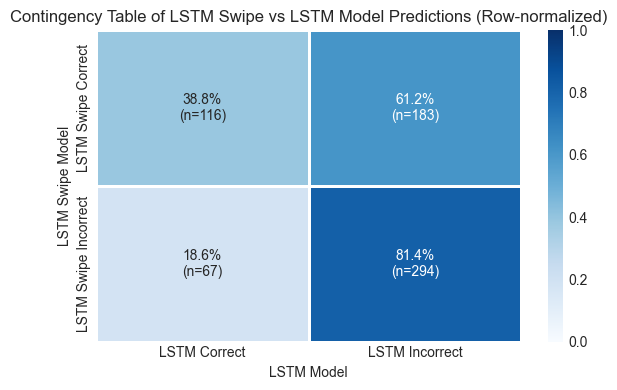

In [19]:
# Draw a graph of the contingency table as a heatmap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

contingency_df = pd.DataFrame(
    contingency_table,
    index=['LSTM Swipe Correct', 'LSTM Swipe Incorrect'],
    columns=['LSTM Correct', 'LSTM Incorrect']
)

# Row-normalized
contingency_df_normalized = contingency_df.div(
    contingency_df.sum(axis=1), axis=0
)

# Build annotation strings: percentage + absolute count
annot = contingency_df_normalized.copy().astype(str)
for i in range(contingency_df.shape[0]):
    for j in range(contingency_df.shape[1]):
        pct = contingency_df_normalized.iloc[i, j]
        count = contingency_df.iloc[i, j]
        annot.iloc[i, j] = f"{pct:.1%}\n(n={count})"

plt.figure(figsize=(6, 4))
sns.heatmap(
    contingency_df_normalized,
    annot=annot,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=1,
)

plt.title("Contingency Table of LSTM Swipe vs LSTM Model Predictions (Row-normalized)")
plt.ylabel("LSTM Swipe Model")
plt.xlabel("LSTM Model")
plt.tight_layout()
plt.show()
